In [1]:
import numpy
print(numpy.__version__)

2.5.1


## Projeto: "Convergência Estatística Aplicada à Precificação de Opções via Modelo Binomial"
Demonstrar empiricamente, através de simulação, como a LFGN, a LGGN e o TLC (via Teorema de De Moivre-Laplace) sustentam o método de precificação de opções por árvore binomial — e quantificar a incerteza da estimativa via Monte Carlo.

In [2]:
import numpy as np
import matplotlib.pyplot as mt
from scipy.stats import binom , norm
import yfinance as yf
import pandas as pd
import requests as rt
import math as M 

Obtenção dos dados que seram usados

In [3]:
dados = yf.download(
    "PETR4.SA",
    period="2y"
)



[*********************100%***********************]  1 of 1 completed


## Modulo  0: preparação e coleta dos dados

Calcular o Log-retorno diario

In [4]:
close  = dados['Close'].squeeze()
razao = close / close.shift(1) # razao entre o fechamento de hoje com o  dia anterior


log = np.log(razao) # calcula o log-retorno diario
log_retorno = log.dropna() 

dp = log_retorno.std() # desvio padrao
dp_anual = dp * np.sqrt(252) # volatilidade anual





print(dp_anual)



0.2451979802115095


Puxando API do banco central

In [5]:
codigo = 11
n = 1
url = f'https://api.bcb.gov.br/dados/serie/bcdata.sgs.{codigo}/dados/ultimos/{n}?formato=json'
resposta = rt.get(url)
selic = resposta.json()
r = float(selic[0]['valor']) # Taxa livre de risco



Extraindo os restante dos dados

In [6]:
s0 = close.iat[-1] # Preço Atual da ação
strike = round(s0) # Preço em exercicio, arredondado
T = 0.25 # tempo de vencimento do mercado
n_steps = 200 # Divide em quantos remos vai ter ate a data de vencimento


OUTPUTS

In [7]:

def outputs(vol):
    deltaT = T/n_steps
    u = M.exp(vol * M.sqrt(deltaT))
    d = 1/u
    p = (M.exp(r * deltaT) - d) / (u - d)

    return u,d, p

u, d, p = outputs(dp_anual)

print(u, d, p)


1.008706742827365 0.9913684102051699 0.5016200744475203


Função  simuladora de trajetoria

In [8]:
# Achando o valor de k 

def simulacao(s, P, sub, des, si, K_strike):
    k = np.random.binomial(s, P)
    Sn = si * (sub ** k) * (des ** (s - k))
    payoff = max(Sn - K_strike, 0)

    return Sn, k, payoff

Sn, k, payoff = simulacao(n_steps, p, u, d, s0, strike)

print(Sn, k, payoff)


46.07612551162462 105 4.076125511624618


## Calculando o preço teorico


In [9]:
esperanca = 0

for l in range(201):
    probk = binom.pmf(k, n_steps, p)  # probabilidade de k altas

    Snk = s0 * (u ** k) * (d ** (n_steps - k))

    payoffk = max(Snk - strike, 0)

    contribuicao = probk * payoffk

    esperanca += contribuicao


def teorico(j, t, e):
    C = np.exp(-j * t) * e
    return C


C = teorico(r, T, esperanca)

print(C)




36.65734774932699


## Modulo 2: Lei Fraca dos Grandes Numeros

# Simulação 

In [10]:

simulacao_N = [10, 100, 1000, 10000]
m_repeticao = 1000

resultados = {}

def estimador_preço(N):
    payoff_N = []

    for m in range(N):
        _, _, pyf= simulacao(n_steps, p, u, d, s0, strike)
        payoff_N.append(float(pyf))

    media_payoff = np.mean(payoff_N)

    Cn = M.exp(-r * T) * media_payoff

    return Cn


for k in simulacao_N:
    Cn_lista = []
    for i in range(m_repeticao):
        cn = estimador_preço(k)
        Cn_lista.append(float(cn))


    resultados[k] = Cn_lista


e = 0.20

margem_erro = {}
for s in simulacao_N:
    v = np.abs(np.array(resultados[s]) - C)
    qtd = np.sum(v > e)

    margem_erro[s] = float(qtd) / 1000
        



print(resultados)
print(margem_erro)






{10: [0.6496015929447958, 1.9729973538518324, 3.4911875440100606, 1.7077362305476234, 0.5874243031914614, 5.328377157565057, 4.410687872962359, 2.1955144842308125, 1.7499397774831364, 3.686228175858488, 1.0146722270133883, 3.577573871413039, 3.242783726055523, 2.2322860081075877, 2.5991734014961767, 1.5980159571067873, 2.3024737080742548, 3.062669130775986, 2.2532220734687702, 1.7178849023392304, 3.9654683335335026, 1.7109046492055209, 1.912563191391954, 3.2528410097302647, 1.0859298364373797, 2.011445912906556, 3.3723969897565538, 2.4105557778299365, 0.696376016146922, 1.1449857550636318, 3.1599019338642638, 2.030932078567695, 2.2411072983637284, 3.0192454097625108, 3.180217210241366, 1.868742773397309, 2.1259495416593244, 2.3588492450918057, 1.7014246094366057, 2.7220595040943074, 2.0116143269265674, 2.0838075977185873, 1.8172384852200325, 2.2891520980262268, 2.2667531234996923, 2.6440802137626447, 3.045998265441229, 2.151667586830663, 2.9933091946859007, 1.083359007027246, 1.8548027

# Grafico

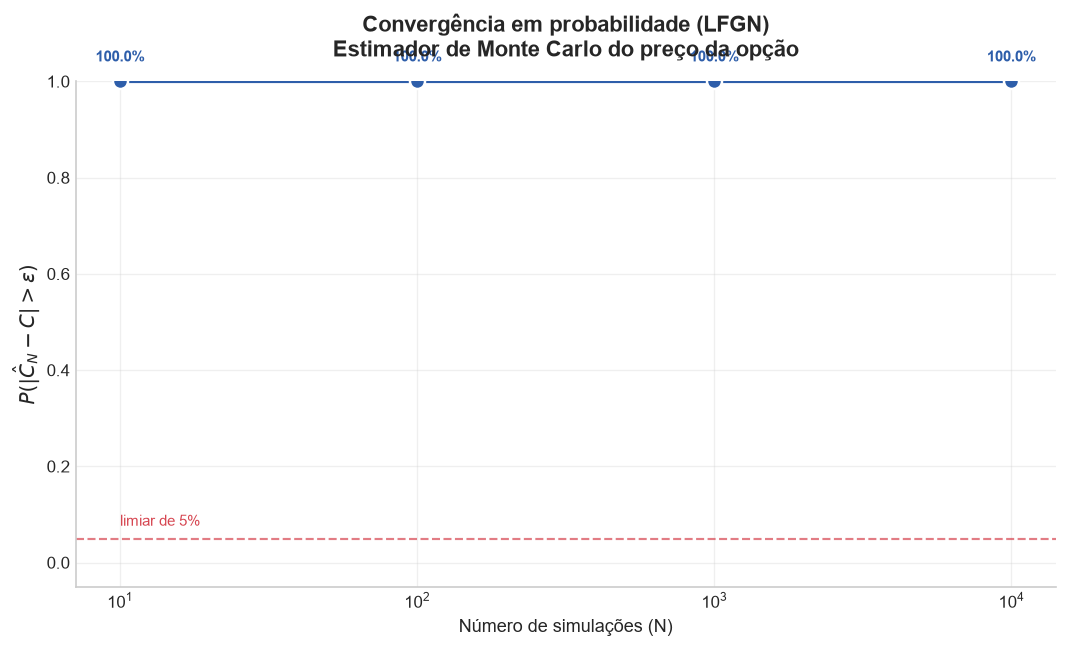

In [11]:
import matplotlib.pyplot as plt

# Estilo geral mais limpo
plt.style.use('seaborn-v0_8-whitegrid')

x = list(margem_erro.keys())
y = list(margem_erro.values())

fig, ax = plt.subplots(figsize=(9, 5.5), dpi=120)

# Linha principal com marcadores maiores e cor customizada
ax.plot(
    x, y,
    marker='o',
    markersize=9,
    linewidth=2.5,
    color='#2E5EAA',
    markerfacecolor='#2E5EAA',
    markeredgecolor='white',
    markeredgewidth=1.5,
    zorder=3
)

# Linha de referência (ex: 5% de erro aceitável)
ax.axhline(y=0.05, color='#D64550', linestyle='--', linewidth=1.3, alpha=0.7, zorder=1)
ax.text(x[0], 0.07, 'limiar de 5%', color='#D64550', fontsize=9, va='bottom')

# Anotações com os valores exatos em cada ponto
for xi, yi in zip(x, y):
    ax.annotate(
        f'{yi*100:.1f}%',
        xy=(xi, yi),
        xytext=(0, 12),
        textcoords='offset points',
        ha='center',
        fontsize=9,
        fontweight='bold',
        color='#2E5EAA'
    )

ax.set_xscale('log')
ax.set_xlabel('Número de simulações (N)', fontsize=11)
ax.set_ylabel(r'$P(|\hat{C}_N - C| > \varepsilon)$', fontsize=12)
ax.set_title('Convergência em probabilidade (LFGN)\nEstimador de Monte Carlo do preço da opção', fontsize=13, fontweight='bold', pad=15)

# Remove bordas superior e direita
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_ylim(-0.05, 1.0)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Modulo 2: Lei Forte dos Grandes Numeros

In [12]:
payoff_soma = []
c = 100000
for z in range(c):
    _, _, pyf = simulacao(n_steps, p, u, d, s0, strike)
    payoff_soma.append(float(pyf))
print(payoff_soma)

soma = np.cumsum(payoff_soma) # Soma acumulada
deno = np.arange(1, c + 1) 

X = soma / deno

Xn = X * M.exp(-r * T)
print(Xn)





[2.505763612416281, 0.0, 0.0, 4.076125511624618, 0.0, 7.3850325215056145, 0.25000000000008527, 3.2841379535526585, 3.2841379535526585, 0.0, 2.505763612416281, 13.757626604711781, 4.076125511624618, 0.0, 0.0, 8.248741826342737, 0.0, 0.0, 0.9889226303228824, 0.0, 4.076125511624618, 2.505763612416281, 4.076125511624618, 10.0217416187838, 4.076125511624618, 0.0, 2.505763612416281, 0.0, 7.3850325215056145, 8.248741826342737, 6.536169235417383, 3.2841379535526585, 0.0, 8.248741826342737, 0.0, 0.0, 0.0, 0.0, 1.74076849505051, 4.076125511624618, 8.248741826342737, 0.0, 14.732788074801974, 0.0, 0.0, 0.0, 9.127556796300922, 0.9889226303228824, 5.701896784683065, 2.505763612416281, 0.25000000000008527, 0.0, 3.2841379535526585, 0.0, 12.79922686844462, 5.701896784683065, 10.93156510164593, 10.93156510164593, 0.0, 4.076125511624618, 0.0, 0.0, 0.0, 5.701896784683065, 0.9889226303228824, 4.076125511624618, 9.127556796300922, 11.85730075400123, 0.0, 7.3850325215056145, 0.0, 0.25000000000008527, 0.0, 0.

Grafico

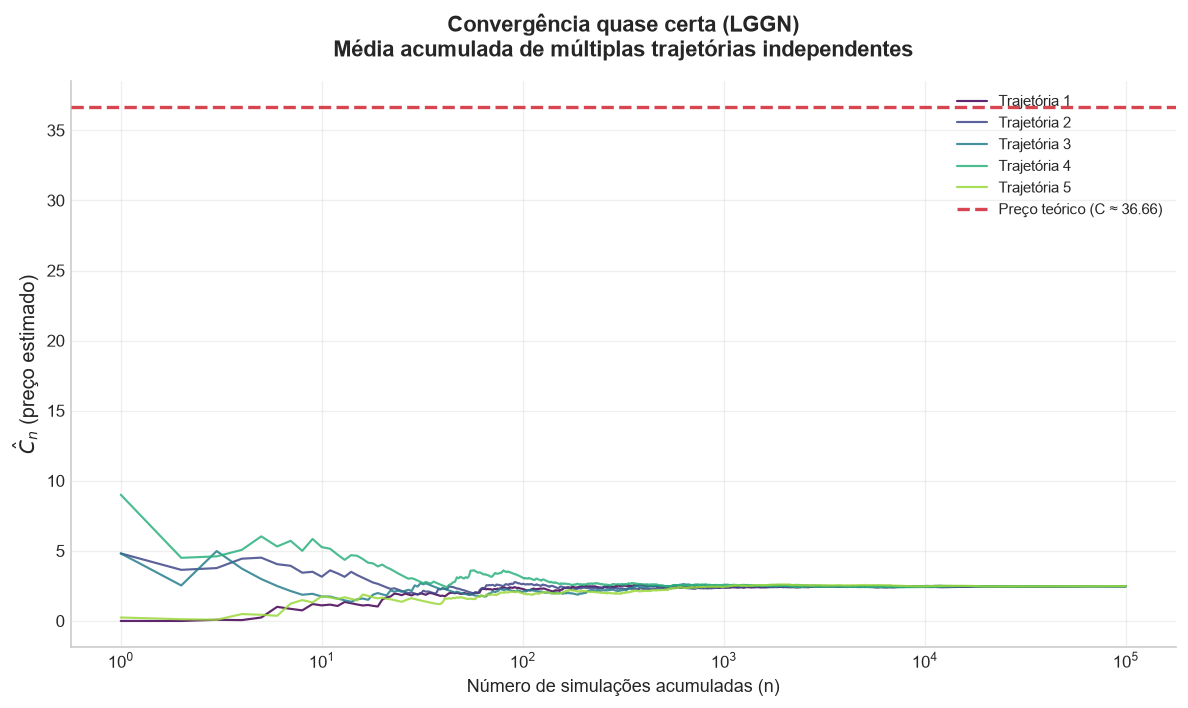

In [13]:
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

fig, ax = plt.subplots(figsize=(10, 6), dpi=120)

# Gera e plota 5 trajetórias diferentes, cada uma com sua própria aleatoriedade
n_trajetorias = 5
cores = plt.cm.viridis(np.linspace(0, 0.85, n_trajetorias))

for idx in range(n_trajetorias):
    payoff_soma = []
    for z in range(c):
        _, _, pyf = simulacao(n_steps, p, u, d, s0, strike)
        payoff_soma.append(float(pyf))

    soma = np.cumsum(payoff_soma)
    deno = np.arange(1, c + 1)
    X = soma / deno
    Xn_traj = X * M.exp(-r * T)

    ax.plot(deno, Xn_traj, linewidth=1.3, alpha=0.85, color=cores[idx], label=f'Trajetória {idx+1}')

# Linha de referência: preço teórico
ax.axhline(y=C, color='#D64550', linestyle='--', linewidth=2, label=f'Preço teórico (C ≈ {C:.2f})', zorder=5)

ax.set_xscale('log')
ax.set_xlabel('Número de simulações acumuladas (n)', fontsize=11)
ax.set_ylabel(r'$\hat{C}_n$ (preço estimado)', fontsize=12)
ax.set_title('Convergência quase certa (LGGN)\nMédia acumulada de múltiplas trajetórias independentes', fontsize=13, fontweight='bold', pad=15)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend(loc='upper right', fontsize=9, framealpha=0.9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Modulo 3

In [25]:
steps = [10, 50, 100, 500, 1000, 5000] # passos variados 

k_variados = {}

i = 100000

for g in steps:
    sort = np.random.binomial(g, p, size=i)
    z = (sort - n *p)/M.sqrt(n * p * (1 - p))
    k_variados[g] = z
    

print(k_variados)




{10: array([ 6.99679658, 12.99682808,  8.99680708, ...,  8.99680708,
        8.99680708,  8.99680708], shape=(100000,)), 50: array([44.99699605, 50.99702755, 46.99700655, ..., 52.99703805,
       44.99699605, 44.99699605], shape=(100000,)), 100: array([ 82.99719553, 106.99732151, 112.99735301, ..., 110.99734251,
       126.9974265 , 100.99729002], shape=(100000,)), 500: array([482.99929526, 452.99913778, 476.99926376, ..., 492.99934775,
       514.99946324, 476.99926376], shape=(100000,)), 1000: array([ 983.00191992, 1011.0020669 ,  987.00194092, ...,  975.00187792,
       1023.00212989,  965.00182543], shape=(100000,)), 5000: array([5099.02352614, 5037.02320068, 5059.02331616, ..., 4937.02267575,
       5077.02341065, 4851.0222243 ], shape=(100000,))}
